# SCARF-MLP Baseline

SCARF (Bahri et al., ICLR 2022) — Self-Supervised Contrastive Learning using Random Feature Corruption.

Faithful reproduction of the published method:
- **Encoder**: 4-layer ReLU MLP, hidden dim 256
- **Pre-training head**: 2-layer ReLU MLP with L2-normalised output
- **Corruption**: 60% of features replaced with draws from empirical marginal distributions
- **Loss**: NT-Xent (InfoNCE) with temperature τ = 1.0
- **Fine-tuning**: encoder unfrozen, classification head replaced with dual SCCI regression heads

Categorical features are one-hot encoded (as in the original paper). Input: 36 numeric + 54 categorical (one-hot) NBI features. No text modality.

Same 5-fold stratified splits, CQR calibration, OOF evaluation, and CAP curve as all other notebooks.

# 1. Model Definition

In [1]:
import torch
import numpy as np
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def pinball_loss(y, q, alpha):
    r = y - q
    return torch.mean(torch.where(r >= 0, alpha * r, (alpha - 1) * r))


class SCARFEncoder(nn.Module):
    """
    SCARF encoder f (Bahri et al., ICLR 2022).
    4-layer ReLU MLP, hidden dim 256.
    """

    def __init__(self, input_dim: int, emb_dim: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class SCARFPretrainHead(nn.Module):
    """
    Pre-training projection head g (Bahri et al., ICLR 2022).
    2-layer ReLU MLP, L2-normalised output.
    """

    def __init__(self, emb_dim: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


class NTXentLoss(nn.Module):
    """
    NT-Xent (InfoNCE) contrastive loss.
    L = (1/N) sum_i -log( exp(s_{i,i}/tau) / ( (1/N) sum_k exp(s_{i,k}/tau) ) )
    where s_{i,j} = cosine_similarity(z_i, z_tilde_j).
    """

    def __init__(self, temperature: float = 1.0):
        super().__init__()
        self.temperature = temperature

    def forward(self, z_anchor, z_positive):
        z_anchor  = F.normalize(z_anchor, dim=-1)
        z_positive = F.normalize(z_positive, dim=-1)
        sim = z_anchor @ z_positive.T / self.temperature
        labels = torch.arange(sim.size(0), device=sim.device)
        return F.cross_entropy(sim, labels)


def corrupt_batch(x, marginals, corruption_rate=0.6):
    """
    SCARF corruption: replace a random subset of features with draws
    from the empirical marginal distribution (Bahri et al., ICLR 2022).
    """
    B, M = x.shape
    x_tilde = x.clone()
    mask = torch.rand(B, M, device=x.device) < corruption_rate
    for j in range(M):
        col_mask = mask[:, j]
        n_corrupt = col_mask.sum().item()
        if n_corrupt > 0:
            draw_idx = torch.randint(0, len(marginals[j]), (n_corrupt,), device=x.device)
            x_tilde[col_mask, j] = marginals[j][draw_idx]
    return x_tilde


class SCARFSCCI(nn.Module):
    """
    Full SCARF model with dual SCCI regression heads.

    mode='pretrain'  — contrastive pretraining (encoder + projection head)
    mode='regress'   — supervised fine-tuning (encoder + SCCI heads)
    """

    def __init__(self, input_dim: int, emb_dim: int = 256):
        super().__init__()
        self.encoder = SCARFEncoder(input_dim, emb_dim)
        self.pretrain_head = SCARFPretrainHead(emb_dim)

        self.scci_head = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, 2),
        )
        self.scci_point_head = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, 1),
        )

    def forward(
        self,
        x,
        x_corrupted          = None,
        y_scci               = None,
        mode:                str   = 'regress',
        alpha:               float = 0.10,
        scci_pinball_weight: float = 1.0,
        scci_point_weight:   float = 1.0,
    ):
        if mode == 'pretrain':
            z_anchor   = self.pretrain_head(self.encoder(x))
            z_positive = self.pretrain_head(self.encoder(x_corrupted))
            return {'z_anchor': z_anchor, 'z_positive': z_positive}

        elif mode == 'regress':
            h = self.encoder(x)

            scci_raw   = self.scci_head(h)
            q_lo       = scci_raw[:, 0]
            q_hi       = q_lo + F.softplus(scci_raw[:, 1])
            scci_point = self.scci_point_head(h).squeeze(-1)

            loss = None
            if y_scci is not None:
                valid = ~torch.isnan(y_scci)
                total = torch.tensor(0.0, device=x.device)
                if valid.sum() > 0:
                    y_v = y_scci[valid]
                    pb  = (pinball_loss(y_v, q_lo[valid], alpha / 2)
                           + pinball_loss(y_v, q_hi[valid], 1.0 - alpha / 2))
                    total = total + scci_pinball_weight * pb
                    total = total + scci_point_weight * F.mse_loss(scci_point[valid], y_v)
                loss = total

            return {
                'scci_direct': {'q_lo': q_lo, 'q_hi': q_hi},
                'scci_point':  scci_point,
                'loss':        loss,
            }

        else:
            raise ValueError(f"Unknown mode: {mode!r}")

# 2. Data Loading

Loads numerical and categorical NBI features. Categorical features are one-hot encoded as in the original SCARF paper (Bahri et al., ICLR 2022). No text modality.

In [3]:
import torch
import numpy as np
import pandas as pd
import json
import ast
from pathlib import Path
from collections import defaultdict
from torch.utils.data import TensorDataset

OMIT_IMPUTED = True
SENTINEL     = -999

# ── PATHS ─────────────────────────────────────────────────────────────────────
BASE_DIR = Path("../data")

with open(BASE_DIR / "metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

numerical_df   = pd.read_csv(BASE_DIR / "numerical.csv")
categorical_df = pd.read_csv(BASE_DIR / "categorical.csv")
labeled_raw    = pd.read_csv(BASE_DIR / "labeled_dataset.csv")
if OMIT_IMPUTED:
    labeled_raw = labeled_raw[labeled_raw['is_cd_min_imputed'] == 0]
    print("Excluding imputed SCCI rows (OMIT_IMPUTED=True)")

numerical_df   = numerical_df.set_index("unified_id")
categorical_df = categorical_df.set_index("unified_id")

shared_ids     = (numerical_df.index
                  .intersection(categorical_df.index))
numerical_df   = numerical_df.loc[shared_ids]
categorical_df = categorical_df.loc[shared_ids]
unified_ids    = shared_ids.tolist()

assert numerical_df.columns.tolist()   == metadata["numerical_columns"]
assert categorical_df.columns.tolist() == metadata["categorical_columns"]

# ── Sentinel remap (before one-hot) ───────────────────────────────────────
num_feature_names = metadata["numerical_columns"]
cat_feature_names = metadata["categorical_columns"]

num_vals = numerical_df.values.copy()
cat_vals = categorical_df.values.copy()

# Drop all-sentinel categorical columns
dead_col_indices = {
    i for i in range(cat_vals.shape[1])
    if set(np.unique(cat_vals[:, i])) == {SENTINEL}
}
if dead_col_indices:
    keep = [i for i in range(cat_vals.shape[1]) if i not in dead_col_indices]
    cat_feature_names = [cat_feature_names[i] for i in keep]
    cat_vals = cat_vals[:, keep]
    print(f"Dropped {len(dead_col_indices)} all-sentinel categorical columns")

# Replace sentinel in numeric with 0
sentinel_num_mask = (num_vals == SENTINEL)
num_vals[sentinel_num_mask] = 0.0
# Replace sentinel in categorical with a dedicated 'missing' category string
cat_df_clean = pd.DataFrame(cat_vals, columns=cat_feature_names)
cat_df_clean = cat_df_clean.replace(SENTINEL, 'MISSING')
cat_df_clean = cat_df_clean.astype(str)

print(f"Numeric features : {num_vals.shape[1]}")
print(f"Categorical features: {cat_df_clean.shape[1]}")
print(f"Sentinel remap: num={sentinel_num_mask.sum():,}")

# ── One-hot encode categoricals (as in SCARF paper) ────────────────────
cat_onehot = pd.get_dummies(cat_df_clean, columns=cat_feature_names, dtype=float)
print(f"One-hot columns  : {cat_onehot.shape[1]}")

# ── Concatenate numeric + one-hot into flat feature matrix ──────────────
X_all = np.hstack([num_vals, cat_onehot.values]).astype(np.float32)
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
INPUT_DIM = X_all.shape[1]
print(f"X_all shape      : {X_all.shape}  (input_dim={INPUT_DIM})")

# ── Build empirical marginals for SCARF corruption ────────────────────
marginals = [torch.tensor(X_all[:, j], dtype=torch.float32) for j in range(INPUT_DIM)]
print(f"Marginals built for {len(marginals)} features")

# ─── Labeled matching ───────────────────────────────────────────────────
TARGET_COLS = ["CD_MIN_filled", "is_cd_min_imputed"]
labeled_raw = labeled_raw[["STRUCTURE_ID"] + TARGET_COLS].copy()
labeled_raw = labeled_raw.dropna(subset=["STRUCTURE_ID", "CD_MIN_filled"])
labeled_raw["STRUCTURE_ID"] = labeled_raw["STRUCTURE_ID"].astype(str).str.strip()
print(f"\nLabeled rows loaded: {len(labeled_raw)}")

structure_to_positions = defaultdict(list)
for pos, uid in enumerate(unified_ids):
    try:
        sid = str(ast.literal_eval(uid)[0]).strip()
        structure_to_positions[sid].append(pos)
    except Exception:
        continue

matched_positions = []
matched_targets   = []
n_not_found = n_ambiguous = n_matched = 0

for _, row in labeled_raw.iterrows():
    sid       = row["STRUCTURE_ID"]
    positions = structure_to_positions.get(sid, [])
    if len(positions) == 0:   n_not_found  += 1; continue
    if len(positions) >  1:   n_ambiguous  += 1; continue
    matched_positions.append(positions[0])
    matched_targets.append({col: row[col] for col in TARGET_COLS})
    n_matched += 1

print(f"\nMatching summary:")
print(f"  Matched (1-to-1)   : {n_matched}")
print(f"  Not found          : {n_not_found}")
print(f"  Ambiguous (dropped): {n_ambiguous}")

# ─── Targets ───
labeled_pos_tensor = torch.tensor(matched_positions, dtype=torch.long)
y_scci = torch.tensor(
    [t["CD_MIN_filled"] for t in matched_targets], dtype=torch.float32
)
is_imputed = torch.tensor(
    [bool(t["is_cd_min_imputed"]) for t in matched_targets], dtype=torch.bool
)

# ─── Build datasets ───
labeled_dataset = TensorDataset(
    X_all_tensor[labeled_pos_tensor],
    y_scci,
    is_imputed,
)
print(f"labeled_dataset   : {len(labeled_dataset)} rows")

total_dataset_pre = TensorDataset(X_all_tensor)
print(f"total_dataset_pre : {len(total_dataset_pre)} rows  (used for contrastive pretraining)")

Excluding imputed SCCI rows (OMIT_IMPUTED=True)
Dropped 5 all-sentinel categorical columns
Numeric features : 36
Categorical features: 54
Sentinel remap: num=24,917
One-hot columns  : 365
X_all shape      : (4914, 401)  (input_dim=401)
Marginals built for 401 features

Labeled rows loaded: 377

Matching summary:
  Matched (1-to-1)   : 370
  Not found          : 7
  Ambiguous (dropped): 0
labeled_dataset   : 370 rows
total_dataset_pre : 4914 rows  (used for contrastive pretraining)


# 3. Config, Model Init & 5-Fold Training + CQR

**Phase 1 — Contrastive pretraining** on all 4,914 unlabelled rows using NT-Xent loss with SCARF corruption (c=0.6, τ=1.0). Hyperparameters follow Bahri et al. (ICLR 2022): Adam, lr=1e-3, batch size 128.

**Phase 2 — Supervised fine-tuning** with encoder unfrozen (as in the original paper). The pre-training projection head g is discarded and replaced with dual SCCI regression heads (quantile + point). 5-fold stratified CV with CQR calibration, identical splits to all other notebooks.

In [4]:
import time
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
import numpy as np

# ── CONFIG ─────────────────────────────────────────────────────────────────
DEVICE           = 'cuda' if torch.cuda.is_available() else 'cpu'
ALPHA            = 0.10

# Pretraining (Bahri et al., ICLR 2022 defaults)
PRETRAIN_EPOCHS  = 1000
PRETRAIN_BS      = 128
PRETRAIN_LR      = 1e-3
CORRUPTION_RATE  = 0.6
TEMPERATURE      = 1.0
PATIENCE_PRE     = 3

# Fine-tuning
FINETUNE_EPOCHS  = 350
FINETUNE_BS      = 32
FINETUNE_LR      = 1e-4
WARMUP_EPOCHS    = 20
N_FINETUNE_FOLDS = 5

EMB_DIM = 256

SCCI_PINBALL_WEIGHT = 2.0
SCCI_POINT_WEIGHT   = 1.0

print(f"Device        : {DEVICE}")
print(f"Input dim     : {INPUT_DIM}")
print(f"Embedding dim : {EMB_DIM}")

# ── MODEL FACTORY ─────────────────────────────────────────────────────
def make_model() -> SCARFSCCI:
    return SCARFSCCI(input_dim=INPUT_DIM, emb_dim=EMB_DIM).to(DEVICE)

_probe   = make_model()
n_params = sum(p.numel() for p in _probe.parameters() if p.requires_grad)
print(f"\nTotal params: {n_params:,}")
del _probe

# ── Move marginals to device ─────────────────────────────────────────
marginals_dev = [m.to(DEVICE) for m in marginals]

# ── TRAINING LOOP (fine-tune phase) ───────────────────────────────
def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total, n = 0.0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            x, y_sc, _ = [t.to(DEVICE) for t in batch]
            out  = model(x, y_scci=y_sc, alpha=ALPHA,
                         scci_pinball_weight=SCCI_PINBALL_WEIGHT,
                         scci_point_weight=SCCI_POINT_WEIGHT)
            loss = out['loss']
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item(); n += 1
    return total / max(n, 1)

def _reset_heads(m: SCARFSCCI):
    def _init(layer):
        if isinstance(layer, nn.Linear):
            nn.init.xavier_uniform_(layer.weight)
            if layer.bias is not None: nn.init.zeros_(layer.bias)
    m.scci_head.apply(_init)
    m.scci_point_head.apply(_init)

# ── PHASE 1 — CONTRASTIVE PRETRAINING ─────────────────────────────
pretrain_ldr = DataLoader(total_dataset_pre, batch_size=PRETRAIN_BS,
                          shuffle=True, pin_memory=False, num_workers=0)
pt_model = make_model()
opt_pre  = optim.Adam(pt_model.parameters(), lr=PRETRAIN_LR)
ntxent   = NTXentLoss(temperature=TEMPERATURE)

print('\n' + '=' * 60)
print(f'PHASE 1 — SCARF contrastive pretraining')
print(f'  {PRETRAIN_EPOCHS} max epochs, {len(total_dataset_pre)} rows, c={CORRUPTION_RATE}, \u03c4={TEMPERATURE}')
print('=' * 60)

best_pre_loss  = float('inf')
best_pre_state = None
patience_ctr   = 0
pre_start      = time.time()

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    pt_model.train()
    total, n = 0.0, 0
    for batch in pretrain_ldr:
        (x,) = [t.to(DEVICE) for t in batch]
        x_corrupted = corrupt_batch(x, marginals_dev, CORRUPTION_RATE)
        out = pt_model(x, x_corrupted=x_corrupted, mode='pretrain')
        loss = ntxent(out['z_anchor'], out['z_positive'])
        opt_pre.zero_grad(); loss.backward(); opt_pre.step()
        total += loss.item(); n += 1
    epoch_loss = total / max(n, 1)

    if epoch_loss < best_pre_loss:
        best_pre_loss  = epoch_loss
        best_pre_state = {k: v.cpu().clone() for k, v in pt_model.state_dict().items()}
        patience_ctr   = 0
    else:
        patience_ctr += 1

    if epoch % 50 == 0:
        elapsed   = time.time() - pre_start
        remaining = (elapsed / epoch) * (PRETRAIN_EPOCHS - epoch)
        print(f'  Epoch {epoch:>4}/{PRETRAIN_EPOCHS}  loss={epoch_loss:.4f}'
              f'  best={best_pre_loss:.4f}  patience={patience_ctr}/{PATIENCE_PRE}'
              f'  ETA {remaining/60:.1f}min')

    if patience_ctr >= PATIENCE_PRE:
        print(f'  Early stopping at epoch {epoch} (patience={PATIENCE_PRE})')
        break

    if torch.isnan(torch.tensor(epoch_loss)):
        print(f'  NaN at epoch {epoch} — stopping'); break

pt_model.load_state_dict({k: v.to(DEVICE) for k, v in best_pre_state.items()})
pretrained_state = {k: v.cpu().clone() for k, v in pt_model.state_dict().items()}
del pt_model
if torch.cuda.is_available(): torch.cuda.empty_cache()
print(f'Phase 1 complete in {(time.time()-pre_start)/60:.1f} min  '
      f'(best loss={best_pre_loss:.4f}, stopped at epoch {epoch})')

# ── STRATIFIED FOLD SPLITS ────────────────────────────────────────
_all_idx     = list(range(len(labeled_dataset)))
_scci_all    = np.array([labeled_dataset[i][1].item() for i in _all_idx])
_scci_bins   = np.digitize(_scci_all, bins=np.percentile(_scci_all, [20, 40, 60, 80]))
_skf         = StratifiedKFold(n_splits=N_FINETUNE_FOLDS, shuffle=True, random_state=42)
_fold_splits = [(ft, cal) for ft, cal in _skf.split(_all_idx, _scci_bins)]

# ── PHASE 2+3 — K-FOLD FINE-TUNING + CQR ──────────────────────────
fold_states = []
run_start   = time.time()

print('\n' + '=' * 60)
print(f'SCARF-MLP  {N_FINETUNE_FOLDS}-fold fine-tuning + CQR')
print('=' * 60)

for fold, (ft_arr, cal_arr) in enumerate(_fold_splits):
    print(f'\n  Fold {fold+1}/{N_FINETUNE_FOLDS} {"-"*40}')

    train_ldr = DataLoader(Subset(labeled_dataset, ft_arr.tolist()),
                           batch_size=FINETUNE_BS, shuffle=True,
                           pin_memory=False, num_workers=0)
    calib_ldr = DataLoader(Subset(labeled_dataset, cal_arr.tolist()),
                           batch_size=256, shuffle=False,
                           pin_memory=False, num_workers=0)
    print(f'    ft={len(ft_arr)}  cal={len(cal_arr)}')

    model = make_model()

    # Load pretrained encoder, discard pretrain head, reset SCCI heads
    model.load_state_dict({k: v.to(DEVICE) for k, v in pretrained_state.items()})
    _reset_heads(model)

    # Encoder unfrozen (as in original SCARF paper)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'    Trainable params: {trainable:,}  (encoder unfrozen)')

    opt = optim.AdamW(model.parameters(), lr=FINETUNE_LR, weight_decay=1e-5)

    warmup = optim.lr_scheduler.LinearLR(opt, 0.1, 1.0, total_iters=WARMUP_EPOCHS)
    cosine = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=FINETUNE_EPOCHS - WARMUP_EPOCHS, eta_min=1e-5)
    sched  = optim.lr_scheduler.SequentialLR(opt, [warmup, cosine], milestones=[WARMUP_EPOCHS])

    best_loss  = float('inf')
    best_state = None
    fold_start = time.time()

    for epoch in range(1, FINETUNE_EPOCHS + 1):
        loss = run_epoch(train_ldr, model, opt)
        sched.step()
        if loss < best_loss:
            best_loss  = loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if epoch % 50 == 0:
            elapsed   = time.time() - fold_start
            remaining = (elapsed / epoch) * (FINETUNE_EPOCHS - epoch)
            print(f'    Epoch {epoch:>3}  loss={loss:.4f}  best={best_loss:.4f}'
                  f'  lr={sched.get_last_lr()[0]:.2e}  ETA {remaining/60:.1f}min')
        if torch.isnan(torch.tensor(loss)):
            print(f'    NaN at epoch {epoch} — stopping'); break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f'    Best weights restored  (loss={best_loss:.4f})')

    # CQR calibration
    model.eval()
    scores = []
    with torch.no_grad():
        for batch in calib_ldr:
            x, y_sc, _ = [t.to(DEVICE) for t in batch]
            out   = model(x, alpha=ALPHA)
            q_lo  = out['scci_direct']['q_lo']
            q_hi  = out['scci_direct']['q_hi']
            valid = ~torch.isnan(y_sc)
            if valid.sum() > 0:
                scores.append(torch.maximum(
                    q_lo[valid] - y_sc[valid],
                    y_sc[valid] - q_hi[valid],
                ).cpu())

    scores   = torch.cat(scores)
    n_cal    = len(scores)
    lvl      = min((1 - ALPHA) * (1 + 1.0 / n_cal), 1.0)
    Q_scci_f = torch.quantile(scores, lvl).item()
    print(f'    CQR Q_scci={Q_scci_f:.4f}  (n_cal={n_cal})')

    fold_states.append({
        'state':   {k: v.cpu().clone() for k, v in model.state_dict().items()},
        'cal_idx': cal_arr.tolist(),
        'Q_scci':  Q_scci_f,
    })
    print(f'    Fold {fold+1} done.')

print(f'\nAll folds complete in {(time.time()-run_start)/60:.1f} min')

# ── HELPERS ───────────────────────────────────────────────────────────
Q_scci = fold_states[0]['Q_scci']

def load_fold(fold_idx):
    global Q_scci, model
    fs    = fold_states[fold_idx]
    model = make_model()
    model.load_state_dict({k: v.to(DEVICE) for k, v in fs['state'].items()})
    model.eval()
    Q_scci = fs['Q_scci']

load_fold(0)
print(f'Active fold: 0  |  Q_scci={Q_scci:.4f}')
print(f'Per-fold Q_scci: {[round(fs["Q_scci"], 4) for fs in fold_states]}')

CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

torch.save({
    "fold_states"      : fold_states,
    "N_FINETUNE_FOLDS" : N_FINETUNE_FOLDS,
    "config": {
        "input_dim"      : INPUT_DIM,
        "emb_dim"        : EMB_DIM,
        "ALPHA"          : ALPHA,
    }
}, CHECKPOINT_DIR / "scarf_folds.pt")
print(f"Fold states saved -> {CHECKPOINT_DIR}")

Device        : cuda
Input dim     : 401
Embedding dim : 256

Total params: 695,811

PHASE 1 — SCARF contrastive pretraining
  1000 max epochs, 4914 rows, c=0.6, τ=1.0
  Early stopping at epoch 32 (patience=3)
Phase 1 complete in 1.6 min  (best loss=4.0840, stopped at epoch 32)

SCARF-MLP  5-fold fine-tuning + CQR

  Fold 1/5 ----------------------------------------
    ft=296  cal=74
    Trainable params: 695,811  (encoder unfrozen)
    Epoch  50  loss=0.8027  best=0.8027  lr=9.82e-05  ETA 0.3min
    Epoch 100  loss=0.2597  best=0.2597  lr=8.76e-05  ETA 0.3min
    Epoch 150  loss=0.1195  best=0.1195  lr=6.97e-05  ETA 0.2min
    Epoch 200  loss=0.0582  best=0.0577  lr=4.86e-05  ETA 0.1min
    Epoch 250  loss=0.0336  best=0.0336  lr=2.89e-05  ETA 0.1min
    Epoch 300  loss=0.0322  best=0.0230  lr=1.50e-05  ETA 0.0min
    Epoch 350  loss=0.0173  best=0.0173  lr=1.00e-05  ETA 0.0min
    Best weights restored  (loss=0.0173)
    CQR Q_scci=1.5938  (n_cal=74)
    Fold 1 done.

  Fold 2/5 ---

# 4. Visualisation & CQR Diagnostics

Point R2=-0.270  Mid R2=-0.240  RMSE=1.329
CQR coverage=90.5% (target>=90%)  AvgWidth=4.083
Per-fold Q_scci: [1.5938, 2.4243, 1.7933, 2.0775, 1.8593]


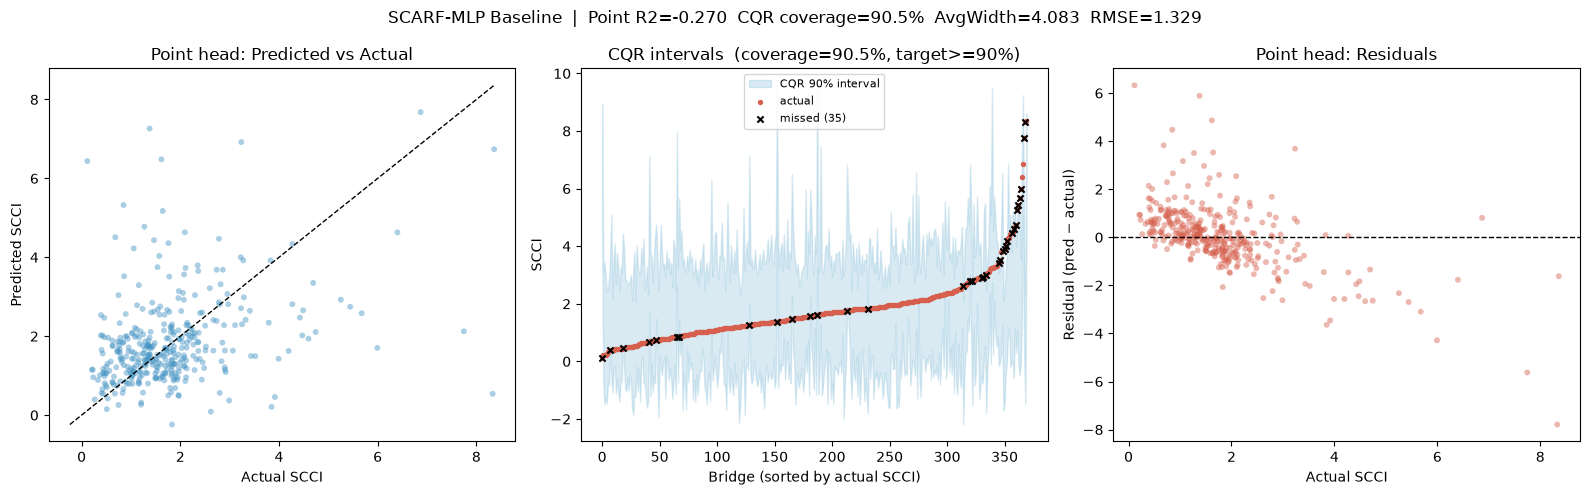

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader, Subset


def collect_scci_preds(fold_idx):
    load_fold(fold_idx)
    loader = DataLoader(
        Subset(labeled_dataset, fold_states[fold_idx]['cal_idx']),
        batch_size=256, shuffle=False, pin_memory=False, num_workers=0,
    )
    q_los, q_his, pts, tgts = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            x, y_sc, _ = [t.to(DEVICE) for t in batch]
            out   = model(x, alpha=ALPHA)
            valid = ~torch.isnan(y_sc)
            q_los.append((out['scci_direct']['q_lo'][valid] - Q_scci).cpu().numpy())
            q_his.append((out['scci_direct']['q_hi'][valid] + Q_scci).cpu().numpy())
            pts.append(out['scci_point'][valid].cpu().numpy())
            tgts.append(y_sc[valid].cpu().numpy())
    return (np.concatenate(q_los), np.concatenate(q_his),
            np.concatenate(pts),   np.concatenate(tgts))


all_qlo, all_qhi, all_pts, all_tgts, all_q = [], [], [], [], []
for fi in range(len(fold_states)):
    qlo, qhi, pts, tgts = collect_scci_preds(fi)
    all_qlo.append(qlo); all_qhi.append(qhi)
    all_pts.append(pts); all_tgts.append(tgts)
    all_q.append(fold_states[fi]['Q_scci'])

q_lo    = np.concatenate(all_qlo)
q_hi    = np.concatenate(all_qhi)
preds   = np.concatenate(all_pts)
targets = np.concatenate(all_tgts)
covered = (targets >= q_lo) & (targets <= q_hi)
mid     = (q_lo + q_hi) / 2

r2_pt   = r2_score(targets, preds)
r2_mid  = r2_score(targets, mid)
rmse    = np.sqrt(np.mean((preds - targets) ** 2))
cov     = covered.mean()
width   = np.mean(q_hi - q_lo)

print(f'Point R2={r2_pt:.3f}  Mid R2={r2_mid:.3f}  RMSE={rmse:.3f}')
print(f'CQR coverage={cov:.1%} (target>=90%)  AvgWidth={width:.3f}')
print(f'Per-fold Q_scci: {[round(q, 4) for q in all_q]}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'SCARF-MLP Baseline  |  Point R2={r2_pt:.3f}  CQR coverage={cov:.1%}'
    f'  AvgWidth={width:.3f}  RMSE={rmse:.3f}',
    fontsize=12,
)

ax = axes[0]
ax.scatter(targets, preds, alpha=0.45, s=18, color='#4393c3', edgecolors='none')
mn, mx = min(targets.min(), preds.min()), max(targets.max(), preds.max())
ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
ax.set_xlabel('Actual SCCI'); ax.set_ylabel('Predicted SCCI')
ax.set_title('Point head: Predicted vs Actual')

ax = axes[1]
order  = np.argsort(targets)
xs     = np.arange(len(targets))
ax.fill_between(xs, q_lo[order], q_hi[order],
                alpha=0.35, color='#92c5de', label='CQR 90% interval')
ax.scatter(xs, targets[order], s=8, color='#d6604d', zorder=3, label='actual')
missed = ~covered[order]
ax.scatter(xs[missed], targets[order][missed], s=20, color='black',
           zorder=4, marker='x', label=f'missed ({missed.sum()})')
ax.set_xlabel('Bridge (sorted by actual SCCI)'); ax.set_ylabel('SCCI')
ax.set_title(f'CQR intervals  (coverage={cov:.1%}, target>=90%)')
ax.legend(fontsize=8)

ax = axes[2]
ax.scatter(targets, preds - targets, alpha=0.45, s=18,
           color='#d6604d', edgecolors='none')
ax.axhline(0, color='k', lw=1, linestyle='--')
ax.set_xlabel('Actual SCCI'); ax.set_ylabel('Residual (pred \u2212 actual)')
ax.set_title('Point head: Residuals')

plt.tight_layout()
plt.show()
load_fold(0)

# 5. OOF Evaluation

In [6]:
from sklearn.metrics import r2_score
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

oof_pts  = np.full(len(labeled_dataset), np.nan)
oof_mids = np.full(len(labeled_dataset), np.nan)
oof_tgts = np.full(len(labeled_dataset), np.nan)

for fold_idx, fs in enumerate(fold_states):
    load_fold(fold_idx)
    cal_loader = DataLoader(Subset(labeled_dataset, fs['cal_idx']),
                            batch_size=256, shuffle=False,
                            pin_memory=False, num_workers=0)
    pts, mids, tgts, idxs = [], [], [], []
    row_ptr = 0
    with torch.no_grad():
        for batch in cal_loader:
            x, y_sc, _ = [t.to(DEVICE) for t in batch]
            out         = model(x, alpha=ALPHA)
            valid       = ~torch.isnan(y_sc)
            batch_size  = x.size(0)
            global_idxs = fs['cal_idx'][row_ptr:row_ptr + batch_size]
            row_ptr    += batch_size
            valid_cpu   = valid.cpu().numpy()
            pts.append(out['scci_point'][valid].cpu().numpy())
            q_lo = out['scci_direct']['q_lo'][valid]
            q_hi = out['scci_direct']['q_hi'][valid]
            mids.append(((q_lo + q_hi) / 2).cpu().numpy())
            tgts.append(y_sc[valid].cpu().numpy())
            idxs.extend([global_idxs[i] for i, v in enumerate(valid_cpu) if v])

    oof_pts[idxs]  = np.concatenate(pts)
    oof_mids[idxs] = np.concatenate(mids)
    oof_tgts[idxs] = np.concatenate(tgts)

valid_mask = ~np.isnan(oof_tgts)
oof_pts    = oof_pts[valid_mask]
oof_mids   = oof_mids[valid_mask]
oof_tgts   = oof_tgts[valid_mask]

r2_pt,  rmse_pt,  mae_pt  = (r2_score(oof_tgts, oof_pts),
                              np.sqrt(np.mean((oof_pts  - oof_tgts)**2)),
                              np.mean(np.abs(oof_pts  - oof_tgts)))
r2_mid, rmse_mid, mae_mid = (r2_score(oof_tgts, oof_mids),
                              np.sqrt(np.mean((oof_mids - oof_tgts)**2)),
                              np.mean(np.abs(oof_mids - oof_tgts)))

W = 60
print()
print('=' * W)
print(f'  SCARF-MLP OOF Evaluation  ({valid_mask.sum()} rows, zero leakage)')
print('=' * W)
print(f"  {'Predictor':<14}  {'R2':>10}  {'RMSE':>10}  {'MAE':>10}")
print(f"  {'-'*48}")
print(f"  {'MSE head':<14}  {r2_pt:+.4f}      {rmse_pt:.4f}      {mae_pt:.4f}")
print(f"  {'Quantile mid':<14}  {r2_mid:+.4f}      {rmse_mid:.4f}      {mae_mid:.4f}")
print()
print('  Each row predicted by the 1 fold model that never trained on it.')

load_fold(0)


  SCARF-MLP OOF Evaluation  (370 rows, zero leakage)
  Predictor               R2        RMSE         MAE
  ------------------------------------------------
  MSE head        -0.2698      1.3292      0.8739
  Quantile mid    -0.2402      1.3136      0.8653

  Each row predicted by the 1 fold model that never trained on it.


# 6. CAP Curve — Shear-Critical Bridge Ranking

Total: 370  |  Shear-critical (SCCI<1): 82 (22.2%)


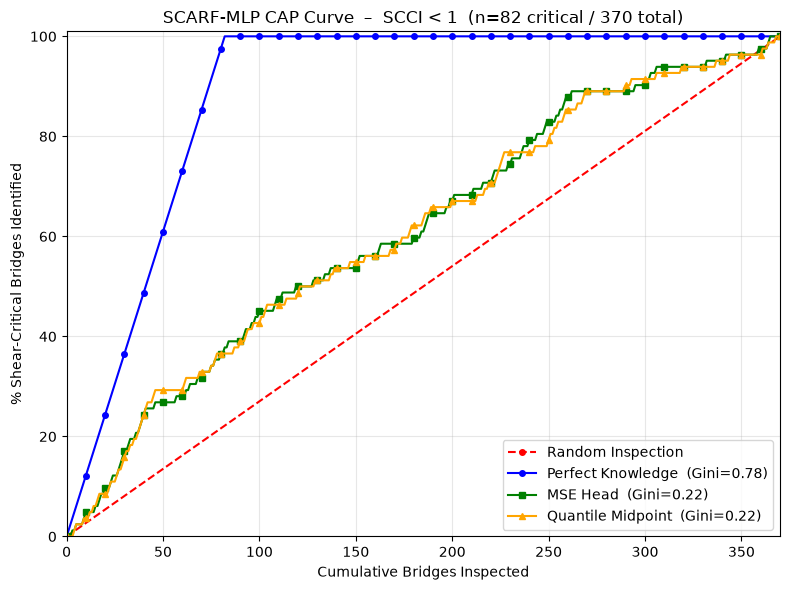

Gini coefficients:
  Perfect Knowledge : 0.7784
  MSE head          : 0.2249  (28.9% of perfect)
  Quantile midpoint : 0.2202  (28.3% of perfect)


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

SCCI_CRITICAL_THRESHOLD = 1

oof_pts  = np.full(len(labeled_dataset), np.nan)
oof_mids = np.full(len(labeled_dataset), np.nan)
oof_tgts = np.full(len(labeled_dataset), np.nan)

for fold_idx, fs in enumerate(fold_states):
    load_fold(fold_idx)
    cal_loader = DataLoader(Subset(labeled_dataset, fs['cal_idx']),
                            batch_size=256, shuffle=False,
                            pin_memory=False, num_workers=0)
    pts, mids, tgts, idxs = [], [], [], []
    row_ptr = 0
    with torch.no_grad():
        for batch in cal_loader:
            x, y_sc, _ = [t.to(DEVICE) for t in batch]
            out         = model(x, alpha=ALPHA)
            valid       = ~torch.isnan(y_sc)
            batch_size  = x.size(0)
            global_idxs = fs['cal_idx'][row_ptr:row_ptr + batch_size]
            row_ptr    += batch_size
            valid_cpu   = valid.cpu().numpy()
            pts.append(out['scci_point'][valid].cpu().numpy())
            q_lo = out['scci_direct']['q_lo'][valid]
            q_hi = out['scci_direct']['q_hi'][valid]
            mids.append(((q_lo + q_hi) / 2).cpu().numpy())
            tgts.append(y_sc[valid].cpu().numpy())
            idxs.extend([global_idxs[i] for i, v in enumerate(valid_cpu) if v])
    oof_pts[idxs]  = np.concatenate(pts)
    oof_mids[idxs] = np.concatenate(mids)
    oof_tgts[idxs] = np.concatenate(tgts)

valid_mask = ~np.isnan(oof_tgts)
pts_v   = oof_pts[valid_mask]
mids_v  = oof_mids[valid_mask]
tgts_v  = oof_tgts[valid_mask]
n_total = len(tgts_v)

is_critical = (tgts_v < SCCI_CRITICAL_THRESHOLD).astype(int)
n_critical  = is_critical.sum()
print(f'Total: {n_total}  |  Shear-critical (SCCI<{SCCI_CRITICAL_THRESHOLD}): {n_critical} ({100*n_critical/n_total:.1f}%)')


def cap_curve(scores_ascending, labels):
    order        = np.argsort(scores_ascending)
    cum_critical = np.cumsum(labels[order])
    x = np.arange(1, n_total + 1)
    y = cum_critical / n_critical * 100
    return np.concatenate([[0], x]), np.concatenate([[0], y])


def gini(x, y):
    rand_y = x / n_total * 100
    return np.trapezoid(y - rand_y, x) / np.trapezoid(100 - rand_y, x)


x_rand = np.array([0, n_total]); y_rand = np.array([0, 100])
x_perf, y_perf = cap_curve(tgts_v, is_critical)
x_pt,   y_pt   = cap_curve(pts_v,  is_critical)
x_mid,  y_mid  = cap_curve(mids_v, is_critical)

g_perf = gini(x_perf, y_perf)
g_pt   = gini(x_pt,   y_pt)
g_mid  = gini(x_mid,  y_mid)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_rand, y_rand, 'r--', marker='o', markersize=4, markevery=10,
        label='Random Inspection')
ax.plot(x_perf, y_perf, 'b-',  marker='o', markersize=4, markevery=10,
        label=f'Perfect Knowledge  (Gini={g_perf:.2f})')
ax.plot(x_pt,   y_pt,   'g-',  marker='s', markersize=4, markevery=10,
        label=f'MSE Head  (Gini={g_pt:.2f})')
ax.plot(x_mid,  y_mid,  color='orange', linestyle='-', marker='^',
        markersize=4, markevery=10,
        label=f'Quantile Midpoint  (Gini={g_mid:.2f})')
ax.set_xlabel('Cumulative Bridges Inspected')
ax.set_ylabel('% Shear-Critical Bridges Identified')
ax.set_title(
    f'SCARF-MLP CAP Curve  \u2013  SCCI < {SCCI_CRITICAL_THRESHOLD}'
    f'  (n={n_critical} critical / {n_total} total)'
)
ax.legend(loc='lower right')
ax.set_xlim(0, n_total); ax.set_ylim(0, 101)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Gini coefficients:')
print(f'  Perfect Knowledge : {g_perf:.4f}')
print(f'  MSE head          : {g_pt:.4f}  ({100*g_pt/g_perf:.1f}% of perfect)')
print(f'  Quantile midpoint : {g_mid:.4f}  ({100*g_mid/g_perf:.1f}% of perfect)')

load_fold(0)